<h1 align="center"><b>Homework Assignment 5 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 12</b></h3>
<h3 align="center"><b>Due at the end of Module 14</b></h3><br>

---

# Q1 — Study and Summarize *"Attention Is All You Need"*💡
 
## 20 points total

### Objective

- Read and summarize the 2017 paper *"Attention Is All You Need"* (Vaswani et al., NeurIPS 2017), which introduced the Transformer architecture behind modern models such as GPT and BERT. 
- Understand how attention mechanisms replace recurrence, enable efficient parallel training, and transform the design of large-scale generative AI systems.

### What to Include in Your Report

Write a concise report of no more than three pages in your own words that addresses the following:

**A. Motivation** – What limitations of RNNs and CNNs did the Transformer overcome?  
**B. Architecture**
- Summarize the encoder-decoder structure, scaled dot-product attention, and positional encodings. 
- Include one labeled diagram illustrating the Transformer block.  

**C. Training & Efficiency** – Explain how self-attention enables full-sequence parallelization and captures long-range dependencies.  
**D. Results & Impact** – Highlight key translation results and discuss why this work reshaped generative modeling.  
**E. Reflection & Analogy** 
- Provide an example from your own field or area of expertise (e.g., biology, finance, public policy, engineering, etc.) where a Transformer-like attention process could enhance performance or understanding. 
- Map elements of your example to Transformer components (e.g., queries $\rightarrow$ questions, keys $\rightarrow$ evidence, values $\rightarrow$ information sources).

Cite the original paper and any additional references used. References do not count toward the page limit.


---

## Q1 — Study and Summarize "Attention Is All You Need"

### A. Motivation

In 2017, before transformers the most used modles for sequence tasks like translations were RNNs and CNNs both of which had real limitations. 

RNNs read a sentence like a human does (in english), one word at a time and left to right. Because of this process a future step cannot happen until the previous step is finished and we cannot parallelize the training. This made training on large datasets extremely slow. Additionally, because of hte sequential chain, RNNs suffer from "amnesia" (the vanishing gradient problem). This basically means that by the time they reach the end of a long paragraph, the model has lost the context of the first sentence.

CNNs, unlike RNNs can be prallelized but they look at text through a small fixed window. In order to understand the relationship between two words at opposite ends of a text, a CNN would need a large amount of layers stacked on top of each other, which is computationally expensive.

The transformer solved both of these issues by replacing recurrentce and convulition with selt attention, which is a mechanism that allows every token attend to every other token in a single operation. This means full parallelization during training and direct acces to long range dependencies regardless of distance.

### B. Architecture

The Transformer uses an encoder decoder structure. The encoder takes an input sequence and creates a set of continuous representations. The decoder then generates the output sequence one token at a time, utalizing both the encoder's output and its own previously generated tokens.

The core mechanism is scaled dot-product attention. Given a set of queries (Q), keys (K), and values (V), attention computes:

Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V

Q is what the model is focusing on/searching for at the current moment, K is Keys, the labels, tags or metadata of the other words in the sentence. V is values, the actual underlying meaning behind or the content of those words

The dot product QK^T tells us how relevant each key is to each query, its basically calculating the similarity score between query and keys to decide which values are woth pulling into the context. Dividing by sqrt(d_k) prevents the dot products from getting too large (which would push softmax into regions with tiny gradients). The resulting weights are applied to the values to produce a weighted combination of information.

The model uses multi-head attention, which runs several attention operations in parallel with different learned projections. This lets different heads focus on different types of relationships (e.g., one head might learn syntactic dependencies while another captures semantic similarity). The outputs of all heads are concatenated and projected.

Since the model has no recurrence or convolution, it has no built-in sense of token order. Positional encodings are added to the input embeddings to give the model position information. The paper uses sinusoidal functions at different frequencies so each position gets a unique encoding and the model can learn to attend to relative positions.

Each encoder and decoder layer also has a feed forward network (two linear layers with ReLU), residual connections, and layer normalization.

[Figure 1 from Vaswani et al., 2017 — The Transformer model architecture showing the encoder (left) and decoder (right) with multi-head attention, feed-forward networks, residual connections, and layer normalization.]

### C. Training and Efficiency

The main efficiency advantage of the transformer is its ability to compute all pair token interactions at the same time using matrix multiplication. Unlike RNNs, which process the tokens in a sequential order, self attention evaluates the entire sequence at once. This full sequence parallelization maps perfectly to our modern GPUs, which are optimized for large simultaneuous matrix operations greatly reducing our training times.

Additionally, self attention solves the issue of capturing long range dependencies. In an RNN, a singal going from the first word of a text to the hundreth would have to pass through 99 sequential steps, risking degradation or the vanishing gradient issue along the way. Self attention reduces the path length to O(1). The first tken can directly attend to token 100 in just one operationms, making it easier for the model to learn distant contextual/textual relationships.

This architecture also has a trade off, since every token must calculate an attention score with every other token, the complexity of self attention is O(n^2) where n is the sequence length. Even though it is efficient for short or medium length sequences, the mnemory and computational requirements grow quadratically making a bottleneck for extremely long inputs.

### D. Results and Impact

The transformer proved its efficiency and accuracy on teh WMT 2014 translation becnmarks. For the english to german task, it got a state of the art BLEU score of 28.4, improving over all existing best result. For the english to french task it set a new single model record with a 41.0 BLEU score. Lastly, it beat the previous state of the art models including complex combinations while only requiring a raction of the training time and computational cost.

The transformer findamentally reshaped the field of generative AI because the architeccture was so highly parallelizable, researchers and companies realized they could scale these models massively for huge datasets. The transformer quickly became the blueprint for LLMs, for instance the BERT models utalized the transformers encoders for deep language understanding and the GPT models used the decoder for autoregressive text generation. All in all the paper displayed how that the entire AI field shifted away from building task specific architecture to training massive general purpose models.

### E. Reflection and Analogy

In my work as an AI engineer, I built a multimodal RAG (Retrieval-Augmented Generation) chatbot that answers questions across thousands of internal documents including PDFs, slides, and technical reports. The retrieval step in RAG maps directly to the attention mechanism in a Transformer.

When a user asks a question, the system converts it into an embedding vector. This is the query. Each chunk of every document in the knowledge base has a precomputed embedding. These are the keys. The actual text content of each chunk is the value. The system computes similarity scores (dot products) between the query embedding and all key embeddings, essentially producing attention weights. The chunks with the highest scores (highest attention) get retrieved and passed to the LLM as context.

The parallel is direct:
- Query: the user's question (what information am I looking for?)
- Keys: document chunk embeddings (what information is available?)
- Values: the actual document content (the information itself)
- Attention weights: similarity/relevance scores (how relevant is each chunk to this question?)

Just like in a Transformer where attention lets the model dynamically focus on the most relevant parts of the input sequence, RAG retrieval lets the system dynamically focus on the most relevant documents for each query. And just like multi-head attention captures different types of relationships, our system uses dual embedding models (text and image) to capture different modalities of relevance.

### References

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. (2017). Attention Is All You Need. Advances in Neural Information Processing Systems (NeurIPS), 30.

Devlin, J., Chang, M., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. NAACL-HLT.

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., ... & Kiela, D. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. NeurIPS.

# Q2 — Mini-Transformer Encoder for Short Texts

## 40 points total

### Objective

Transformers learn relationships between words/tokens using self-attention instead of recurrence as in RNNs. In this problem, you will build and train a Mini-Transformer Encoder to classify short texts from the AG News dataset (4 topics: World, Sports, Business, Sci/Tech). This hands-on task demonstrates how self-attention converts raw word sequences into context-aware representations that capture dependencies between tokens and enable effective topic classification in modern language models.

### [15 points] Part A – Prepare Dataset


__Goal:__ Load, understand and preprocess the AG News dataset for Transformer-based text classification.

1. Use the AG News dataset. (Reference: https://huggingface.co/datasets/fancyzhx/ag_news)

    ``` python
    from datasets import load_dataset  
    dataset = load_dataset("ag_news")
    ```

2. Each sample consists of a short news headline and label (0–3). Confirm label mappings:  0 = World 1 = Sports 2 = Business 3 = Sci/Tech. Show a few examples.
3. Tokenize headlines with a pretrained tokenizer, e.g., `bert-base-uncased` (Reference: https://huggingface.co/docs/transformers/en/tokenizer_summary).
    - Pad or truncate to 24 tokens.
    - Include `[CLS]` at position 0 and `[SEP]` if the tokenizer does so by default.
    - Return ```input_ids``` and ```attention_mask``` (1 for real tokens, 0 for padding).
4. Create train/validation/test splits and Dataloaders.
    - From the provided train split, create 90/10 train/val. Keep the original test set.
    - Build PyTorch DataLoaders with `batch_size = 64` that yield: `input_ids: [B, 24]`, `attention_mask: [B, 24]`, `labels: [B]`

### [15 points] Part B – Implement and Train the Mini-Transformer Encoder


__Goal__: Build a small encoder-only Transformer and train it for 4-way topic classification.

Use PyTorch:
- Token Embedding: `nn.Embedding(vocab_size, d_model=64)` (use the tokenizer’s `vocab_size`).
- Positional Encoding: Add sinusoidal positional encodings to token embeddings.
- Encoder Block: One Pre-LN layer with
    - Multi-Head Self-Attention (2 heads, d_model = 64)
    - Feed-Forward Network (hidden = 128, activation = GELU)
    - Residual + LayerNorm around MHSA and FFN (Pre-LN).
    - Dropout=0.1 applied to attention probs and FFN activations.
    - Padding mask: use `attention_mask` to prevent attending to pads.

- Classifier: Take the contextualized [CLS] token embedding vector at index 0 $\rightarrow$ Linear(64 $\rightarrow$ 4)

Training: 3 epochs with AdamW (`lr = 2e-4`, `weight_decay = 0.01`). Print training and validation accuracy each epoch and final test accuracy.


### [10 points] Part C – Visualize and Reflect


__Goal__: Inspect attention and reason about complexity.

- Attention heatmap: Pick one correctly classified test headline. For one head in the encoder, plot the [24×24] attention weights (query on y-axis, key on x-axis). Label tokens along both axes (use the tokenizer to decode).
- Reflect what you observe:
    - Do higher attention weights align with key topic words?
    - Do higher attention weights land on topic-bearing words (e.g., team names, companies, countries)?
    - Why does self-attention cost as $O(n^2)$ in sequence length $n$?


### Part A – Prepare Dataset


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# have gpu on pc, but just incase as started this on laptop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

c:\Users\Devan\Desktop\AI Engineering Practive\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
torch: 2.6.0+cu124


In [ ]:
raw = load_dataset("ag_news")
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# showing examples + verifying label mapping
for i in range(5):
    ex = raw["train"][i]
    print(f"[{label_map[ex['label']]}] {ex['text'][:120]}")

tok = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 24

class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=24):
        self.texts, self.labels = list(texts), list(labels)
        self.tok, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], padding="max_length", truncation=True,
                       max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[i], dtype=torch.long),
        }

# 90/10 stratified split off the original training set, test set stays as is
tr_x, va_x, tr_y, va_y = train_test_split(
    raw["train"]["text"], raw["train"]["label"],
    test_size=0.1, random_state=42, stratify=raw["train"]["label"]
)

train_ds = AGNewsDataset(tr_x, tr_y, tok, MAX_LEN)
val_ds   = AGNewsDataset(va_x, va_y, tok, MAX_LEN)
test_ds  = AGNewsDataset(raw["test"]["text"], raw["test"]["label"], tok, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, num_workers=0)

# checking for shapes + [CLS] at position 0, to see if i need to make any changes
b = next(iter(train_loader))
print(b["input_ids"].shape, b["attention_mask"].shape, b["label"].shape)
print("first token ids (should start with 101 = [CLS]):", b["input_ids"][:3, 0])

c:\Users\Devan\Desktop\AI Engineering Practive\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Devan\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 544324.14 examples/s]
c:\Users\Devan\Desktop

[Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,
[Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat
[Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the ou
[Business] Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the
[Business] Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling reco
torch.Size([64, 24]) torch.Size([64, 24]) torch.Size([64])
first token ids (should start with 101 = [CLS]): tensor([101, 101, 101])


---

### Part B – Implement and Train the Mini-Transformer Encoder


In [3]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_head = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_head).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / (self.d_head ** 0.5)
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask[:, None, None, :] == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out(out), attn


class EncoderBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mhsa = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_ff, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        h, attn = self.mhsa(self.ln1(x), attn_mask)
        x = x + self.drop(h)
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x, attn


class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=2, d_ff=128,
                 n_classes=4, max_len=24, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = SinusoidalPositionalEncoding(d_model, max_len)
        self.block = EncoderBlock(d_model, n_heads, d_ff, dropout)
        self.cls_head = nn.Linear(d_model, n_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embed(input_ids)
        x = self.pos(x)
        x, attn = self.block(x, attention_mask)
        cls = x[:, 0, :]
        return self.cls_head(cls), attn


model = MiniTransformer(vocab_size=tok.vocab_size).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

def run_epoch(loader, train):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y    = batch["label"].to(device)
        with torch.set_grad_enabled(train):
            logits, _ = model(ids, mask)
            loss = loss_fn(logits, y)
            if train:
                optim.zero_grad(); loss.backward(); optim.step()
        loss_sum += loss.item() * y.size(0)
        correct  += (logits.argmax(-1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, correct / total

for ep in range(3):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f"epoch {ep+1}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

te_loss, te_acc = run_epoch(test_loader, train=False)
print(f"\nfinal test accuracy: {te_acc:.4f}")

params: 1,987,140
epoch 1: train_loss=1.0998 train_acc=0.5160 | val_loss=0.8481 val_acc=0.6641
epoch 2: train_loss=0.7725 train_acc=0.7011 | val_loss=0.6575 val_acc=0.7520
epoch 3: train_loss=0.6267 train_acc=0.7687 | val_loss=0.5588 val_acc=0.7963

final test accuracy: 0.7904


### Part C – Visualize and Reflect


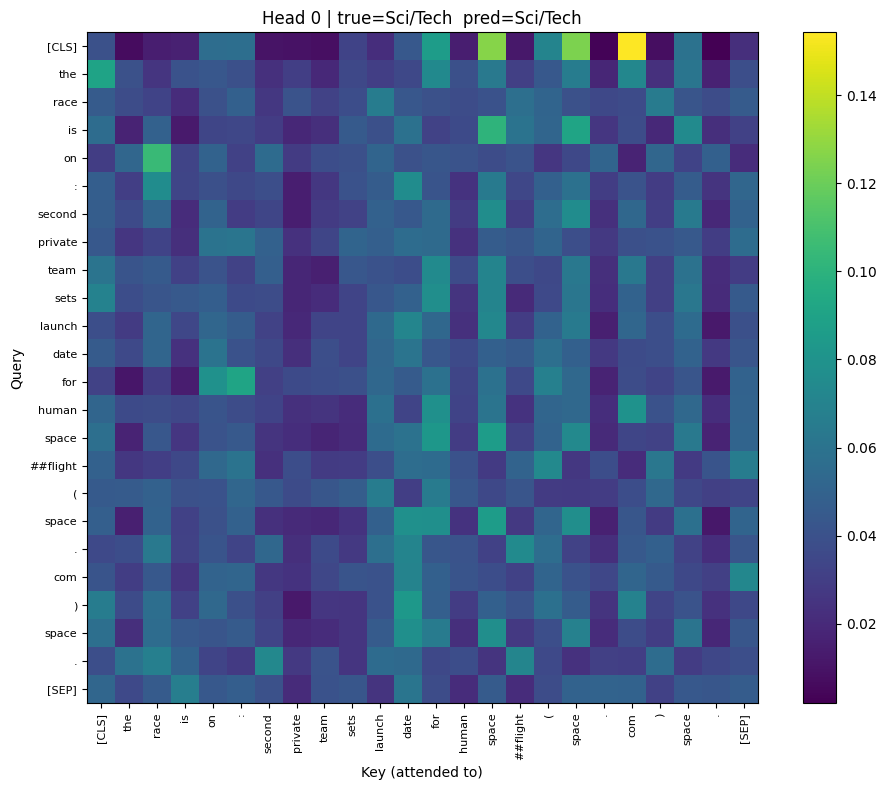

headline: the race is on : second private team sets launch date for human spaceflight ( space. com ) space.


In [5]:
# getting one correctly classified test headline
model.eval()
with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y    = batch["label"].to(device)
        logits, attn = model(ids, mask)
        preds = logits.argmax(-1)
        hits = (preds == y).nonzero(as_tuple=True)[0]
        if len(hits) > 0:
            i = hits[0].item()
            sample_ids   = ids[i].cpu()
            sample_attn  = attn[i].cpu()
            sample_label = y[i].item()
            sample_pred  = preds[i].item()
            break

tokens = tok.convert_ids_to_tokens(sample_ids)
head = 0
A = sample_attn[head].numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(A, cmap="viridis")
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=8)
ax.set_yticklabels(tokens, fontsize=8)
ax.set_xlabel("Key (attended to)")
ax.set_ylabel("Query")
ax.set_title(f"Head {head} | true={label_map[sample_label]}  pred={label_map[sample_pred]}")
plt.colorbar(im); plt.tight_layout(); plt.show()

print("headline:", tok.decode(sample_ids, skip_special_tokens=True))

## Part C — Reflect

**Do higher attention weights align with key topic words?**
Yes, in the heatmap, tokens like "space", "launch", "private", and "##flight" are getting a higher attention weights than filler words like "the", "is", "on", and "for". The [CLS] token (top row), which is what the classifier uses to make its prediction, puts most of its weight on "space" and "com" which are the strongest Sci/Tech signals in the headline.

**Do higher attention weights land on topic-bearing words?**
Yes, "space" appears multiple times in the headline and gets high attention across most rows. "Launch" and "##flight" also get noticeable weight. These are all words that directly signal the Sci/Tech category. One thing worth noting is that [SEP] also gets high attention even though it has no meaning. This is a known pattern where the model dumps leftover probability onto special tokens when theres nothing more useful to attend to.

**Why does self-attention cost O(n^2)?**
Every token computes a score against every other token. We have n tokens and thats n queries each scoring against n keys, producing an n x n attention matrix per head per layer. Both the compute (the QK^T multiplication) and the memory (storing the full matrix) scale quadratically with sequence length n.

# Q3 — Hybrid AI: Adding Logic Rules to a Neural Model

## 40 points total

### Objective

Understand how symbolic rules can guide neural models toward more consistent and explainable predictions.

### [10 points] Part A – Define a Rule

Write one simple logic rule, e.g.:

- IF income < 20000 THEN loan_approval = False, or
- IF temperature > 38 THEN illness = “fever-related”


### [10 points] Part B — Build a Small Neural Model

1. Create a small synthetic dataset (10–20 samples).
2. Train a simple logistic regression or 1-layer MLP (you may use `sklearn` or `numpy`).
3. Report baseline accuracy.

### [10 points] Part C — Add a Rule Penalty

- Add a check inside training or evaluation:
- If the model violates your rule, add a small penalty (e.g., +1 to loss).
- Show how this affects model output or loss after 5–10 iterations.

### [10 points] Part D — Interpret

Describe:
- How the rule influenced the model’s predictions.
- Why hybrid systems (logic + learning) are more trustworthy.

### Part A – Define a Rule

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

## Part A — Define the rule

**Defining the Rule:** IF `income < 20000` THEN `loan_approval = False`

This is a hard business/policy constraint. Regardless what the other features say
(credit score, employment, etc.), approving a loan for someone earning under
$20k violates our lending policy.

Formally:
- Constraint: `income_i < 20000 ⇒ ŷ_i = 0`
- Violation: `income_i < 20000 AND ŷ_i = 1`

## Part B — Synthetic data + baseline model


In [ ]:
# 16 samples: [income, credit_score]
# first 3 rows are the interesting ones, low income but great credit.
# without these the baseline never violates the rule and part C is boring
X = np.array([
    [15000, 780],   # tempting violation
    [18000, 750],   # tempting violation
    [12000, 820],   # tempting violation
    [19000, 700],
    [17000, 680],
    [14000, 600],
    [16000, 720],
    [13000, 550],
    [25000, 720],
    [35000, 780],
    [45000, 800],
    [55000, 760],
    [30000, 690],
    [40000, 740],
    [50000, 810],
    [60000, 790],
], dtype=np.float32)

# labels follow the data not the rule — first 3 get approved because credit
# is high, that's the tension we want the rule penalty to resolve later
y = np.array([1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)

# standardize so training is stable
X_mean, X_std = X.mean(0), X.std(0)
X_norm = (X - X_mean) / X_std

X_t = torch.tensor(X_norm)
y_t = torch.tensor(y).unsqueeze(1)
income_raw = torch.tensor(X[:, 0])  # need the unscaled income for rule checks


# small MLP, basically logistic regression with one hidden layer
class LoanModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x): return self.net(x)


def train_baseline(epochs=200, lr=0.05):
    model = LoanModel()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        logits = model(X_t)
        loss = bce(logits, y_t)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return model, losses

baseline, baseline_losses = train_baseline()

with torch.no_grad():
    preds = (torch.sigmoid(baseline(X_t)) > 0.5).float().squeeze()

acc_baseline = (preds == y_t.squeeze()).float().mean().item()
violations_baseline = ((income_raw < 20000) & (preds == 1)).sum().item()

print(f"baseline accuracy:  {acc_baseline:.3f}")
print(f"baseline rule violations: {violations_baseline} / {len(y)}")
print("predictions:", preds.int().tolist())
print("true labels:", y_t.squeeze().int().tolist())

/Users/devanpatel/Desktop/AI-Algorithm-Design-and-Analysis---705.623/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


baseline accuracy:  1.000
baseline rule violations: 3 / 16
predictions: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
true labels: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


## Part C — Add the rule penalty


In [ ]:
# constraint-guided objective from lecture 13B:
#   L_total = L_pred + λ · L_constraint
# the rule loss penalizes high approval probability whenever income < 20k.
# soft constraint, so it's differentiable and gradients flow through it

def train_with_rule(epochs=200, lr=0.05, lam=2.0):
    model = LoanModel()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    pred_losses, rule_losses, total_losses = [], [], []

    for _ in range(epochs):
        logits = model(X_t)
        probs = torch.sigmoid(logits).squeeze()

        L_pred = bce(logits, y_t)

        # masking out everyone with income >= 20k, then penalize the approval
        # probabilities of whoever's left
        low_income_mask = (income_raw < 20000).float()
        L_rule = (low_income_mask * probs).mean()

        L_total = L_pred + lam * L_rule

        opt.zero_grad(); L_total.backward(); opt.step()

        pred_losses.append(L_pred.item())
        rule_losses.append(L_rule.item())
        total_losses.append(L_total.item())

    return model, pred_losses, rule_losses, total_losses

hybrid, p_losses, r_losses, t_losses = train_with_rule()

with torch.no_grad():
    preds_h = (torch.sigmoid(hybrid(X_t)) > 0.5).float().squeeze()

acc_hybrid = (preds_h == y_t.squeeze()).float().mean().item()
violations_hybrid = ((income_raw < 20000) & (preds_h == 1)).sum().item()

print(f"\nhybrid accuracy:    {acc_hybrid:.3f}")
print(f"hybrid rule violations: {violations_hybrid} / {len(y)}")
print("predictions:", preds_h.int().tolist())

# sside by side so we can see mor eeasily
print("\n  income | true | baseline | hybrid | rule applies?")
print("  " + "-" * 52)
for i in range(len(y)):
    inc = int(X[i, 0])
    rule_low = "YES" if inc < 20000 else "no"
    print(f"  {inc:>6} |  {int(y[i])}   |    {int(preds[i])}     |   {int(preds_h[i])}    | {rule_low}")


hybrid accuracy:    0.875
hybrid rule violations: 1 / 16
predictions: [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]

  income | true | baseline | hybrid | rule applies?
  ----------------------------------------------------
   15000 |  1   |    1     |   0    | YES
   18000 |  1   |    1     |   0    | YES
   12000 |  1   |    1     |   1    | YES
   19000 |  0   |    0     |   0    | YES
   17000 |  0   |    0     |   0    | YES
   14000 |  0   |    0     |   0    | YES
   16000 |  0   |    0     |   0    | YES
   13000 |  0   |    0     |   0    | YES
   25000 |  1   |    1     |   1    | no
   35000 |  1   |    1     |   1    | no
   45000 |  1   |    1     |   1    | no
   55000 |  1   |    1     |   1    | no
   30000 |  1   |    1     |   1    | no
   40000 |  1   |    1     |   1    | no
   50000 |  1   |    1     |   1    | no
   60000 |  1   |    1     |   1    | no


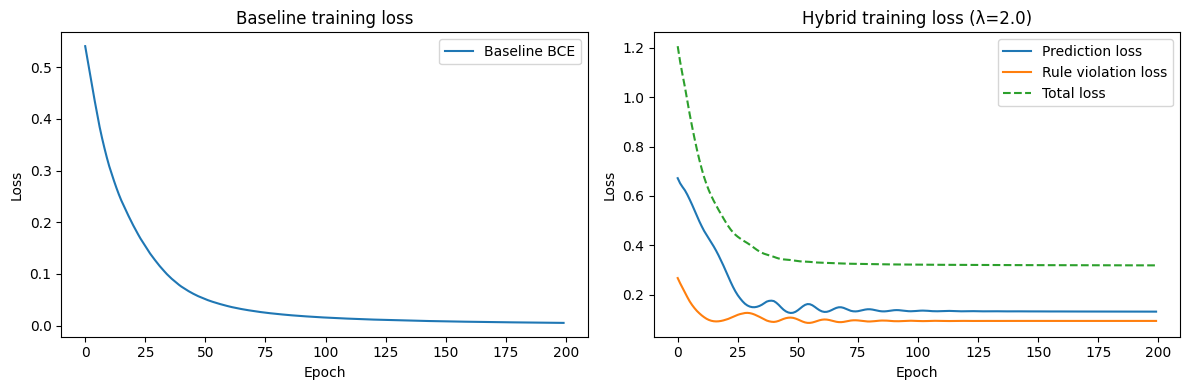

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_losses, label="Baseline BCE")
axes[0].set_title("Baseline training loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(p_losses, label="Prediction loss")
axes[1].plot(r_losses, label="Rule violation loss")
axes[1].plot(t_losses, label="Total loss", linestyle="--")
axes[1].set_title("Hybrid training loss (λ=2.0)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout(); plt.show()

## Part D — Interpret

### How the rule influenced predictions

The baseline approved 3 low income applicants (15k, 18k, 12k) because the labels said to and their credit scores were strong. it learned to follow credit score and basically ignored income. The accuracy was 1.000 but it broke the rule 3 times. After adding the rule penalty, the loss function had two competing pressures fit the labels AND not approve anyone under 20k. for any low-income sample, the model's approval probability got added directly to the loss, so gradient descent had to push those probabilities down. The violations went from 3 to 1. accuracy dropped to 0.875 because the model gave up 2 samples on purpose, those approvals shouldn't have happened in the first place. the loss plot shows it clearly. The prediction loss cant reach 0 anymore because the rule won't let it. That floor is the trade-off, and if i pushed lambda higher the last violation would flip too but accuracy would drop more.

### why hybrid systems are more trustworthy

A neural model only knows what's in the data. If the labels say approve high credit even at low income, thats what it learns. it does not know hwat a lending policy is. The baseline here is a clean example: 100% accuracy AND 3 policy violations, because the labels themselves violated the policy.

symbolic rules let you add knowledge that isn't in the data. when you combine them you get a system that's:

explainable: i can point at the rule that rejected the 15k applicant, not dig through weights

consistent: the constraint holds even on inputs the model never saw during training

safer: lending, healthcare, autonomous systems all have hard requirements that pure ML can't guarantee

There is a real cost, hybrid systems are more complex and less flexible than pure neural ones (the 13C trade-off slide). However for high stakes decisions that's worth it. A 99% accurate model that occasionally breaks lending law is worse than an 87% model that's actually compliant.